<a href="https://colab.research.google.com/github/lithikaneelakandan56-ctrl/ml_practice/blob/main/ML/day07_random_forest_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
print(X.head())
print(y.value_counts())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [2]:
# data preprocessing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
# eda has done same as decision tree
#building random forest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [4]:
# model evaluation
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



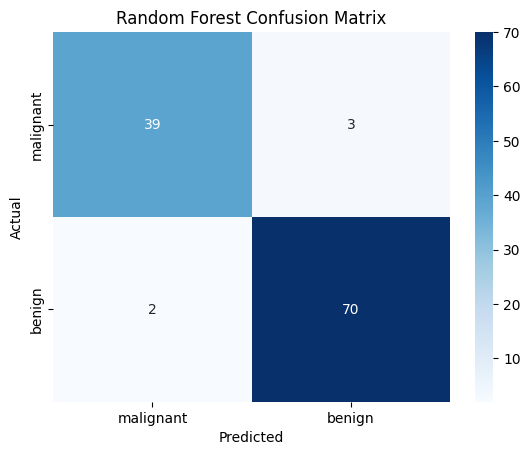

In [5]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

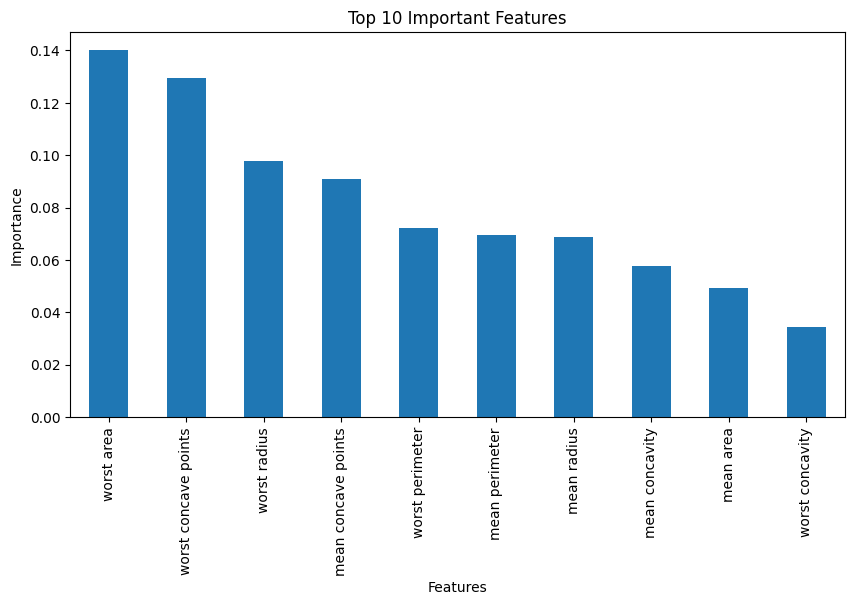

In [6]:
# feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
importance.head(10).plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [7]:
for n in [10, 50, 100, 200]:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    print("Trees:", n)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("F1 Score:", f1_score(y_test, pred))

Trees: 10
Accuracy: 0.9385964912280702
F1 Score: 0.951048951048951
Trees: 50
Accuracy: 0.956140350877193
F1 Score: 0.9655172413793104
Trees: 100
Accuracy: 0.956140350877193
F1 Score: 0.9655172413793104
Trees: 200
Accuracy: 0.956140350877193
F1 Score: 0.9655172413793104


In [8]:
# user input prediction
import pandas as pd
print("Enter the tumour details:")
user_values = []
for feature in X.columns:
    value = float(input(f"Enter {feature}: "))
    user_values.append(value)
# Convert user input into DataFrame
user_input = pd.DataFrame([user_values], columns=X.columns)
# Predict
prediction = model.predict(user_input)
# Display result
if prediction[0] == 0:
    print("\nPrediction: Malignant")
else:
    print("\nPrediction: Benign")

Enter the tumour details:
Enter mean radius: 13
Enter mean texture: 12
Enter mean perimeter: 44
Enter mean area: 23
Enter mean smoothness: 45
Enter mean compactness: 23
Enter mean concavity: 34
Enter mean concave points: 56
Enter mean symmetry: 67
Enter mean fractal dimension: 57
Enter radius error: 45
Enter texture error: 56
Enter perimeter error: 67
Enter area error: 88
Enter smoothness error: 79
Enter compactness error: 6
Enter concavity error: 5
Enter concave points error: 4
Enter symmetry error: 3
Enter fractal dimension error: 2
Enter worst radius: 9
Enter worst texture: 6
Enter worst perimeter: 7
Enter worst area: 5
Enter worst smoothness: 9
Enter worst compactness: 0
Enter worst concavity: 56
Enter worst concave points: 45
Enter worst symmetry: 56
Enter worst fractal dimension: 77

Prediction: Benign


In [9]:
probability = model.predict_proba(user_input)
print("Malignant Probability:", probability[0][0] * 100, "%")
print("Benign Probability:", probability[0][1] * 100, "%")

Malignant Probability: 43.0 %
Benign Probability: 56.99999999999999 %
